In [13]:
import custom.tools as tl
import custom.models as mod
import os
import torch 
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle

if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.backends.cudnn.benchmark = True
else: device = torch.device('cpu')
print(f'Selected device: {device}')

Selected device: cuda


In [32]:
# full sample reconstruction (multivariate & univariate mode, have different dimensions arrangement, this is for multivariate)
# sample_full = torch.hstack([sample[0, 0, :]] + [sample[0, i, -win_stride:] for i in range(1, sample.shape[1])])
# out_full = torch.hstack([out[0, 0, :]] + [out[0, i, -win_stride:] for i in range(1, out.shape[1])])
sample_full = torch.hstack([sample[0, 0, :]] + [sample[i, -win_stride:, 0] for i in range(1, sample.shape[1])])
out_full = torch.hstack([out[0, 0, :]] + [out[i, -win_stride:, 0] for i in range(1, out.shape[1])])

In [33]:
torch.max(nn.MSELoss(reduction='none')(sample_full, out_full))

tensor(0.1484)

## Remote Run

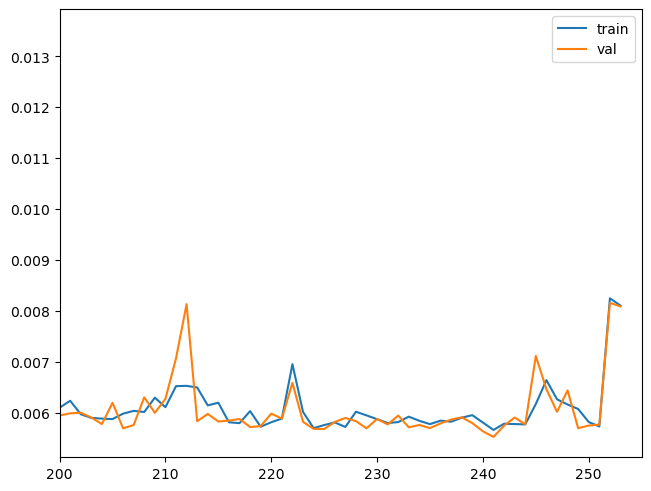

In [9]:
with open('/mnt/eph/uni_feat_model_stuff/trial_20/losses_255.pickle', 'rb') as fin: losses = pickle.load(fin)
fig, ax = plt.subplots(layout='constrained')
ax.plot(losses['train'][1:], label='train')
ax.plot(losses['val'][1:], label='val')
ax.set_xlim([200, 255])
# ax.set_ylim([0.005, .008])
ax.legend()
plt.show()

torch.Size([4352, 100, 1]) torch.Size([4352, 100, 1])


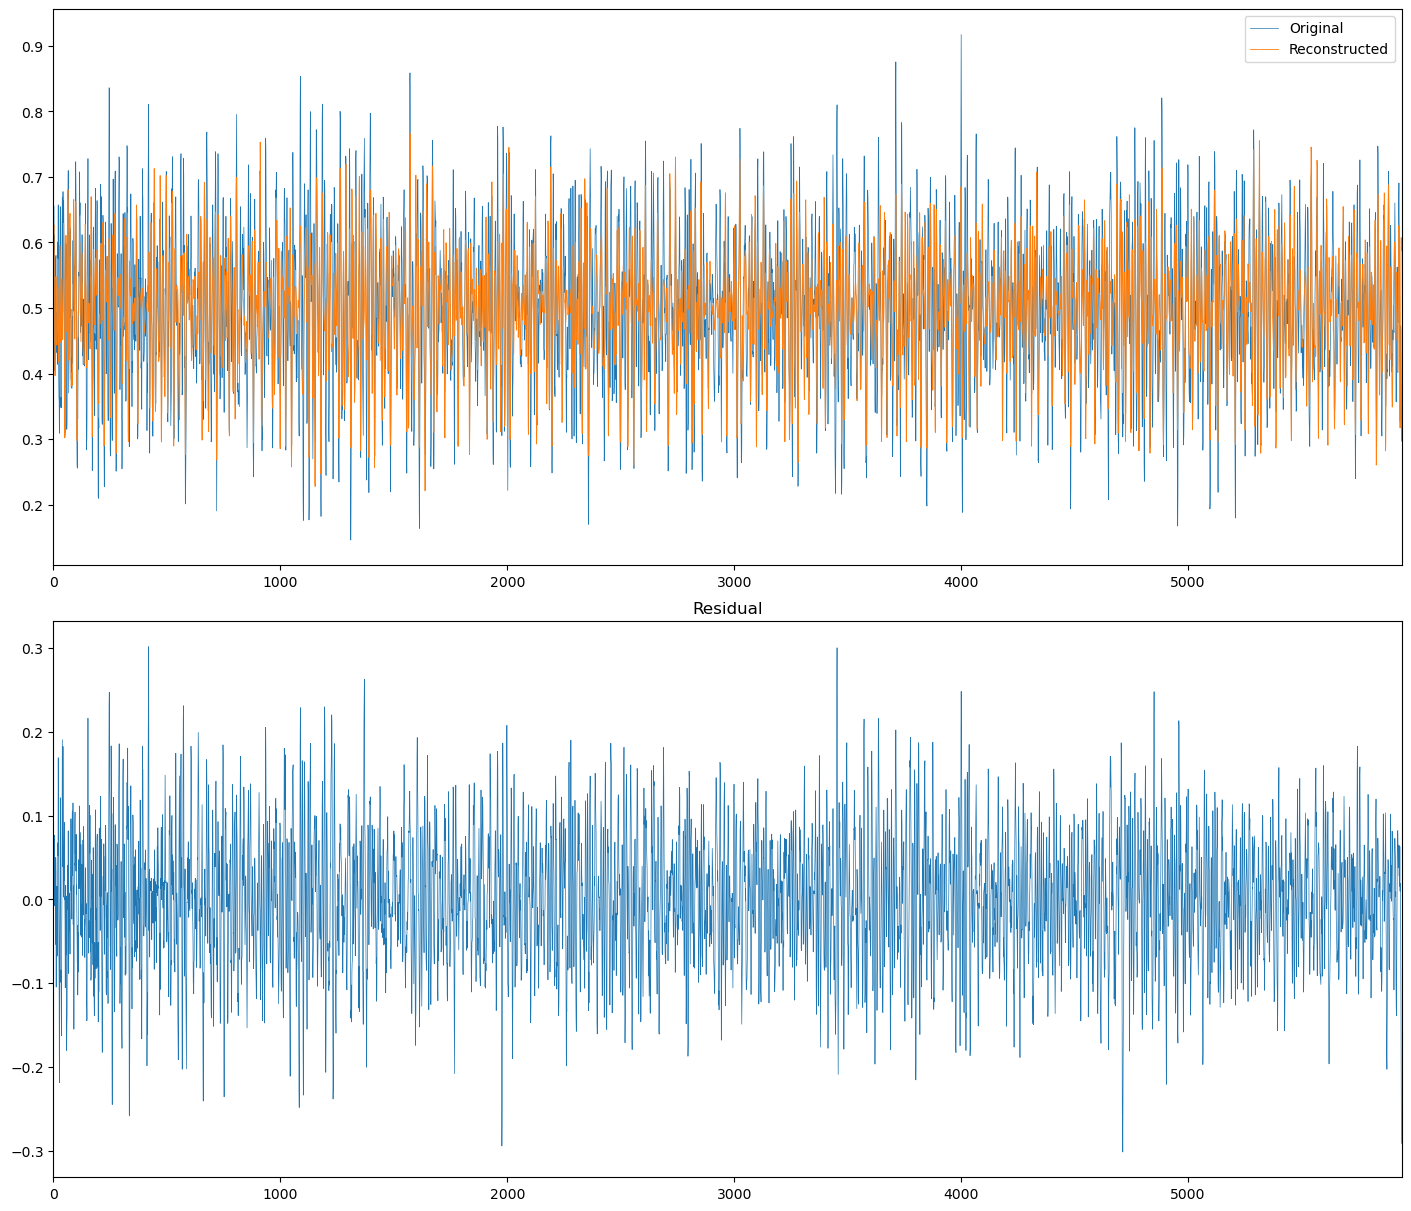

In [21]:
last_save = torch.load('/mnt/eph/uni_feat_model_stuff/trial_20/mod_opt_scal_230.pt', weights_only=False)
## Useful parameters:
win_len = 100
win_stride = 60
num_workers = 10
persistent_workers = False

h5_path = "/mnt/eph/data/L1_70_12_6_6.h5"
test = tl.h5set(h5_path, win_len=win_len, win_stride=win_stride, name='C')

test_loader = DataLoader(test, batch_size=16, pin_memory=True, num_workers=num_workers, persistent_workers=persistent_workers)
sample = list(test_loader)[-1].reshape(-1, 100, 1).to(device)

loss_func = nn.MSELoss()
model = mod.LSTMAEUni().to(device)
model = torch.compile(model)
model.load_state_dict(last_save['model_state_dict'])

model.eval()
with torch.no_grad():
    with torch.autocast(device_type=str(device), dtype=torch.float16): out = model(sample)
sample = sample.to('cpu')
out = out.to('cpu')
print(sample.shape, out.shape)
sample_full = torch.hstack([sample[0, 0, :]] + [sample[i, -win_stride:, 0] for i in range(1, sample.shape[1])])
out_full = torch.hstack([out[0, 0, :]] + [out[i, -win_stride:, 0] for i in range(1, out.shape[1])])
fig, ax = plt.subplots(2, 1, figsize=(14, 12), layout='constrained')
ax[0].plot(sample_full, lw=0.5, label='Original')
ax[0].plot(out_full, lw=.6, label='Reconstructed')
ax[0].legend()

ax[1].plot(sample_full - out_full, lw=.5)
ax[1].set_title('Residual')
for Ax in ax: Ax.set_xlim((0, len(sample_full)))
plt.show()